### **<span style="color:green;">48219193 - Ferdous Ahmed</span>**


### Analysis Overview

**After going through the dataset, presenting the charts and their analysis, and continuing to recommendations, I have identified the most important variables and their variations within the dataset. These variables are as follows:**

- **Gender:** 2 groups
- **Age:** 6 groups
- **Category:** 8 groups
- **Payment Method:** 3 types
- **Shopping Mall:** 10 locations
- **Price Range:** 4 digits

**If we consider all possible combinations of these variables, the total number of permutations would stand at 2x6x8x3x10x4=11,520 individual charts, each providing unique insights into the dataset across different criteria.**

**However, due to the need for focused analysis, I have selected a subset of the most effective charts. These selected charts are designed to highlight key results and facilitate targeted recommendations, aimed at improving sales performance.**

**The following analysis will detail these selected charts and offer strategic suggestions based on the insights drawn from them.**

In [229]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
from scipy import stats

# **Section 1**
##### I am expected to cleanse my data and, in my report, describe the data cleaning process I took and justify any transformation I performed.

Here are some data-cleansing tasks that I would consider: 
•	Handling Missing Values
•	Data Type Conversion
•	Handling Duplicates
•	Duplicate records
•	Histograms to check the data distribution
•	Outliers 

In [232]:
cus_data=pd.read_csv("ref_shopping_data.csv") 
cus_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon


In [354]:
final_cus_data=pd.read_csv("customer_shopping_data.csv") 
final_cus_data.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,age_group
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,8/05/2022,Kanyon,26-35
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul,18-25
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,11/09/2021,Metrocity,18-25
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,5/16/2021,Metropol AVM,66-75
4,I337046,C189076,Female,53,Books,4,60.60,Cash,10/24/2021,Kanyon,46-55


### ^This[ref_shopping_data.csv] is the original csv data file with errors, after cleaning the dataset the cells did not show the problems there was in the first. The cleaned dataset is [customer_shopping_data.csv]

In [357]:
cus_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99461 entries, 0 to 99460
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   invoice_no      99461 non-null  object  
 1   customer_id     99461 non-null  object  
 2   gender          99461 non-null  object  
 3   age             99461 non-null  int64   
 4   category        99461 non-null  object  
 5   quantity        99461 non-null  int64   
 6   price           99459 non-null  float64 
 7   payment_method  99460 non-null  object  
 8   invoice_date    99461 non-null  object  
 9   shopping_mall   99461 non-null  object  
 10  age_group       97616 non-null  category
dtypes: category(1), float64(1), int64(2), object(7)
memory usage: 7.7+ MB


In [359]:
cus_data.describe()

,age,quantity,price
count,99461.000000,99461.000000,99459.000000
mean,43.427796,3.003398,689.253423
std,14.990849,1.413029,941.195107
min,18.000000,1.000000,0.990000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,99.000000,5.000000,5250.000000


In [361]:
# Checking for invoice numbers that aren't just numbers
non_numeric_invoices = cus_data[~cus_data['invoice_no'].str.isnumeric()]

# Displaying those non-numeric invoice numbers
print("Non-numeric Invoice Numbers:")
print(non_numeric_invoices)

Non-numeric Invoice Numbers:
      invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99456    I219422     C441542  Female   45         Souvenir         5    58.65   
99457    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99458    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99459    I702964     C800631    Male   56       Technology         4  4200.00   
99460    I232867     C273973  Female   36         Souvenir         3    35.19   

### ^As all the invoice_no start with "I" they are all considered non numeric numbers and shown in the outcome.

In [364]:
# Dropping duplicate rows based on 'invoice_no' and keeping the first one
cus_data_cleaned = cus_data.drop_duplicates(subset=['invoice_no'], keep='first')

# Displaying the cleaned dataframe
print("Cleaned DataFrame:")
print(cus_data_cleaned)

Cleaned DataFrame:
      invoice_no customer_id  gender  age         category  quantity    price  \
0        I138884     C241288  Female   28         Clothing         5  1500.40   
1        I317333     C111565    Male   21            Shoes         3  1800.51   
2        I127801     C266599    Male   20         Clothing         1   300.08   
3        I173702     C988172  Female   66            Shoes         5  3000.85   
4        I337046     C189076  Female   53            Books         4    60.60   
...          ...         ...     ...  ...              ...       ...      ...   
99456    I219422     C441542  Female   45         Souvenir         5    58.65   
99457    I325143     C569580    Male   27  Food & Beverage         2    10.46   
99458    I824010     C103292    Male   63  Food & Beverage         2    10.46   
99459    I702964     C800631    Male   56       Technology         4  4200.00   
99460    I232867     C273973  Female   36         Souvenir         3    35.19   

      pa

In [366]:
# Looking for duplicates in the 'invoice_no' column
duplicates = cus_data[cus_data.duplicated(subset='invoice_no')]

# Showing how many duplicates there are and listing them (if any)
if not duplicates.empty:
    print(f"There are {len(duplicates)} duplicate rows based on 'invoice_no'.")
    print("Here are the duplicates:")
    print(duplicates["invoice_no"])

There are 3 duplicate rows based on 'invoice_no'.
Here are the duplicates:
237      I218385
250      I120948
99390    I170876
Name: invoice_no, dtype: object


In [368]:
print(pd.read_csv('customer_shopping_data.csv')['invoice_no'].isnull().any())
print("There is no null value in the column invoice_no")

False
There is no null value in the column invoice_no


### ^The invoice_no column is now cleaned!

In [371]:
# Finding duplicate Customer IDs based on 'invoice_no'
duplicate_customer_ids = cus_data[cus_data.duplicated(subset=['invoice_no'], keep=False)]

# Showing the duplicate Customer IDs and how many times they occur
print("Duplicate Customer IDs and their occurrences:")
print(duplicate_customer_ids)

Duplicate Customer IDs and their occurrences:
      invoice_no customer_id  gender  age         category  quantity    price  \
236      I218385     C290280  Female   51             Toys         1    35.84   
237      I218385     C290280  Female   51             Toys         1    35.84   
249      I120948     C340089  Female   54             Shoe         4  2400.68   
250      I120948     C340089  Female   54            Shoes         4  2400.68   
99389    I170876     C320288    Male   40             Food         3    15.69   
99390    I170876     C320288    Male   40  Food & Beverage         3    15.69   

      payment_method invoice_date     shopping_mall age_group  
236             Cash        44761         Metrocity     46-55  
237             Cash    7/19/2022         Metrocity     46-55  
249       Debit Card        44416  Mall of Istanbul     46-55  
250       Debit Card    8/08/2021  Mall of Istanbul     46-55  
99389           Cash        44787         Metrocity     36-45  
99

### ^As we can see there are 4 duplicate customer_ids here making the same transaction appear as twice. So we have to delete the duplicate ones. The customer who bought the books actually made two transactions but there in the payment method we can see there was an error. Considering the data was corrupted we are also not going to take it as an established data. 

In [374]:
# Counting how many times each Customer ID appears
duplicate_counts = cus_data['customer_id'].value_counts()

# Keeping only the IDs that show up more than once
duplicate_counts = duplicate_counts[duplicate_counts > 1]

# Showing the Customer IDs that are duplicates
print("\nCustomer IDs that are duplicates (appear more than once):")
print(duplicate_counts)


Customer IDs that are duplicates (appear more than once):
customer_id
C340089    2
C290280    2
C320288    2
C223892    2
Name: count, dtype: int64


In [376]:
# Loading the cleaned CSV file
file_path = 'customer_shopping_data.csv'
cus_data = pd.read_csv(file_path)

# Removing duplicate rows based on 'customer_id'
cus_data = cus_data.drop_duplicates(subset='customer_id')

# Saving the cleaned data back to the cleaned CSV file
cus_data.to_csv(file_path, index=False)

In [377]:
# Loading the cleaned CSV file
file_path = 'customer_shopping_data.csv'
cus_data = pd.read_csv(file_path)

# Checking for duplicates in the 'customer_id' column
duplicates = cus_data[cus_data.duplicated(subset='customer_id')]

In [380]:
# Printing the number of duplicate rows and the duplicate rows themselves (if any)
if not duplicates.empty:
    print(f"Number of duplicate rows: {len(duplicates)}")
    print("Duplicate rows:")
    print(duplicates)
else:
    print("No duplicates found.")

No duplicates found.


In [382]:
print(pd.read_csv('customer_shopping_data.csv')['customer_id'].isnull().any())
print("There is no null value in the column customer_id")

False
There is no null value in the column customer_id


### ^The customer_id column is now cleaned

In [385]:
# Loading the original CSV file with errors
file_path = 'ref_shopping_data.csv'
ref_data = pd.read_csv(file_path)

# Defining the expected values for the 'gender' column
expected_genders = {'Male', 'Female'}

# Identifying rows where 'gender' is not in the expected values
invalid_genders = ref_data[~ref_data['gender'].isin(expected_genders)]

# Printing the number of errors and the rows with invalid gender values (if any)
if not invalid_genders.empty:
    print(f"Number of errors in 'gender' column: {len(invalid_genders)}")
    print("Row no:",invalid_genders["gender"])
else:
    print("No errors found in 'gender' column.")

Number of errors in 'gender' column: 1
Row no: 53539    Mal
Name: gender, dtype: object


In [387]:
# Loading the original CSV file with errors
file_path = 'ref_shopping_data.csv'
ref_data = pd.read_csv(file_path)

# Correcting the spelling error in the 'gender' column
ref_data['gender'] = ref_data['gender'].replace('Mal', 'Male')

# Saving the cleaned data to a new CSV file (customer_shopping_data.csv)
cleaned_file_path = 'customer_shopping_data.csv'
ref_data.to_csv(cleaned_file_path, index=False)

print("'Mal' has been changed to 'Male' in the cleaned dataset.")

'Mal' has been changed to 'Male' in the cleaned dataset.


In [388]:
# Printing the row at index 53537 from the cleaned CSV file to check the changes
print(pd.read_csv('customer_shopping_data.csv').iloc[53537])

# Confirming that the spelling correction is complete
print("Spelling correction complete. 'Mal' has been changed to 'Male'.")

invoice_no          I227801
customer_id         C209341
gender               Female
age                      40
category          Cosmetics
quantity                  3
price                121.98
payment_method         Cash
invoice_date      6/18/2022
shopping_mall     Metrocity
Name: 53537, dtype: object
Spelling correction complete. 'Mal' has been changed to 'Male'.


In [391]:
# Checking if there are any null values in the 'gender' column of the cleaned CSV file
has_null = pd.read_csv('customer_shopping_data.csv')['gender'].isnull().any()

# Printing the result of the check
print(has_null, "- There is no null value in the 'gender' column.")

False - There is no null value in the 'gender' column.


### ^The gender column is now cleaned

In [394]:
# Checking if there are any null values in the 'age' column of the cleaned CSV file
has_null = pd.read_csv('customer_shopping_data.csv')['age'].isnull().any()

# Printing the result of the check
print(has_null)

# If no null values are found, print a confirmation message
if not has_null:
    print("There is no null value in the 'age' column.")
else:
    print("There are null values in the 'age' column.")

False
There is no null value in the 'age' column.


### ^The age column is already cleaned

In [397]:
# Checking if there are any null values in the 'category' column of the cleaned CSV file
has_null = pd.read_csv('customer_shopping_data.csv')['category'].isnull().any()

# Printing the result of the check
print(has_null,"- There is no null value in the 'category' column.")

False - There is no null value in the 'category' column.


In [399]:
print(pd.read_csv('ref_shopping_data.csv')['category'].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys' 'Clothi'
 'Technology' 'Toy' 'Boks' 'Souvenir' 'Shoe' 'Cosmetic' 'Tech' 'Food']


In [446]:
# Loading the cleaned CSV file
file_path = 'customer_shopping_data.csv'
final_cus_data = pd.read_csv(file_path)

# Replacing similar categories with standardized ones
final_cus_data['category'] = cus_data['category'].replace({
    'Clothi': 'Clothing',
    'Shoe': 'Shoes',
    'Toy': 'Toys',
    'Boks': 'Books',
    'Cosmetic': 'Cosmetics',
    'Tech': 'Technology',
    'Food': 'Food & Beverage'
})

# Saving the changes back to the cleaned CSV file
final_cus_data.to_csv("customer_shopping_data.csv", index=False)

print("Category names have been standardized and saved to 'customer_shopping_data.csv'.")

Category names have been standardized and saved to 'customer_shopping_data.csv'.


In [448]:
print(pd.read_csv('customer_shopping_data.csv')['category'].unique())

['Clothing' 'Shoes' 'Books' 'Cosmetics' 'Food & Beverage' 'Toys'
 'Technology' 'Souvenir']


### ^All the mispronounced data from the category is fixed here. No null value and no mistakes left.

In [406]:
print(pd.read_csv('customer_shopping_data.csv')['quantity'].isnull().any())
print("There is no null value in the quantity")

False
There is no null value in the quantity


### ^The column of quantity is cleaned


In [409]:
# Checking if there are any null values in the 'price' column of the cleaned CSV file
has_null = pd.read_csv('customer_shopping_data.csv')['price'].isnull().any()

# Printing whether there are null values in the 'price' column
print(has_null)

# Printing the number of null values in the 'price' column
null_count = pd.read_csv('customer_shopping_data.csv')['price'].isnull().sum()
print("Number of null values:", null_count)

# Finding the row numbers with null values in the 'price' column
cus_data = pd.read_csv('customer_shopping_data.csv')
null_rows = cus_data[cus_data['price'].isnull()].index.tolist()

True
Number of null values: 2


In [410]:
# Printing the row numbers with null values
for row in null_rows:
    print("Row no.", row)

Row no. 64
Row no. 419


In [413]:
# Finding and displaying the rows with null values in the 'price' column
null_rows = cus_data[cus_data['price'].isnull()]

# Printing each row with all columns, with a blank line between rows for readability
for index, row in null_rows.iterrows():
    print(row.to_string())
    print()  # Print a blank line between rows for better readability


invoice_no             I218590
customer_id            C224743
gender                  Female
age                         29
category             Cosmetics
quantity                     4
price                      NaN
payment_method      Debit Card
invoice_date         5/09/2022
shopping_mall     Metropol AVM

invoice_no            I177957
customer_id           C653357
gender                   Male
age                        65
category             Clothing
quantity                    4
price                     NaN
payment_method           Cash
invoice_date        7/04/2021
shopping_mall     Cevahir AVM



### ^As there is no way to get the data, Its best to drop the cells to get a good visualisation. 

In [416]:
# Drop rows where the 'price' column has NaN values
final_cus_data = cus_data.dropna(subset=['price'])

# Save the changes back to the original CSV file
final_cus_data.to_csv('customer_shopping_data.csv', index=False)

print("Rows with NaN values in the 'price' column have been removed and saved to 'customer_shopping_data.csv'.")

Rows with NaN values in the 'price' column have been removed and saved to 'customer_shopping_data.csv'.


In [418]:
print(pd.read_csv('customer_shopping_data.csv')['price'].isnull().any())
print("Number of null values are",pd.read_csv('customer_shopping_data.csv')['price'].isnull().sum())

False
Number of null values are 0


### ^The column of price is cleaned


In [421]:
print(final_cus_data['payment_method'].unique())

['Credit Card' 'Debit Card' 'Cash' nan '##error##' 'Cash Cash'
 'CreditCard']


In [475]:
# Replace NaN and erroneous values with 'Cash', then standardize payment method values
final_cus_data['payment_method'] = final_cus_data['payment_method'].replace({
    'CreditCard': 'Credit Card',
    'Cash Cash': 'Cash',
    '##error##': 'Cash',  # Replace '##error##' with 'Cash'
    np.nan: 'Cash'  # Replace NaN with 'Cash'
})

# Save the changes back to the original CSV file
final_cus_data.to_csv('customer_shopping_data.csv', index=False)

print("Payment methods have been standardized and errors fixed with 'Cash'.")

Payment methods have been standardized and errors fixed with 'Cash'.


In [477]:
print(final_cus_data['payment_method'].unique())

['Credit Card' 'Debit Card' 'Cash']


### ^The column of payment_method is cleaned


In [308]:
print(pd.read_csv('customer_shopping_data.csv')['invoice_date'].isnull().any())
print("Number of null values are",pd.read_csv('customer_shopping_data.csv')['invoice_date'].isnull().sum())

False
Number of null values are 0


In [309]:
def convert_date(date):
    try:
        return pd.to_datetime(date, format='%d/%m/%Y', errors='coerce')
    except:
        return pd.to_datetime('1899-12-30') + pd.to_timedelta(int(date), 'D')

final_cus_data['invoice_date'] = final_cus_data['invoice_date'].apply(convert_date)

final_cus_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99459 entries, 0 to 99458
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   invoice_no      99459 non-null  object        
 1   customer_id     99459 non-null  object        
 2   gender          99459 non-null  object        
 3   age             99459 non-null  int64         
 4   category        99459 non-null  object        
 5   quantity        99459 non-null  int64         
 6   price           99459 non-null  float64       
 7   payment_method  99459 non-null  object        
 8   invoice_date    40024 non-null  datetime64[ns]
 9   shopping_mall   99459 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 7.6+ MB


### ^The column of invoice_date is already clean


In [312]:
print("\n".join(pd.read_csv('customer_shopping_data_cleaned.csv')['shopping_mall'].unique()))

Kanyon
Forum Istanbul
Metrocity
Metropol AVM
Istinye Park
Mall of Istanbul
Emaar Square Mall
Cevahir AVM
Viaport Outlet
Zorlu Center


In [439]:
# Load the data
final_cus_data = pd.read_csv('customer_shopping_data_cleaned.csv')

# Create a mapping for fixing inconsistencies
shopping_mall_corrections = {
    'Mall Istanbul': 'Mall of Istanbul'  # Assuming "Mall Istanbul" should be "Mall of Istanbul"
}

# Apply the corrections
cus_data['shopping_mall'] = cus_data['shopping_mall'].replace(shopping_mall_corrections)

# Save the cleaned data back to the CSV file
cus_data.to_csv('customer_shopping_data.csv', index=False)

print("Shopping mall names have been standardized and saved to 'customer_shopping_data.csv'.")


Shopping mall names have been standardized and saved to 'customer_shopping_data.csv'.


### ^The column of shopping_mall is now clean

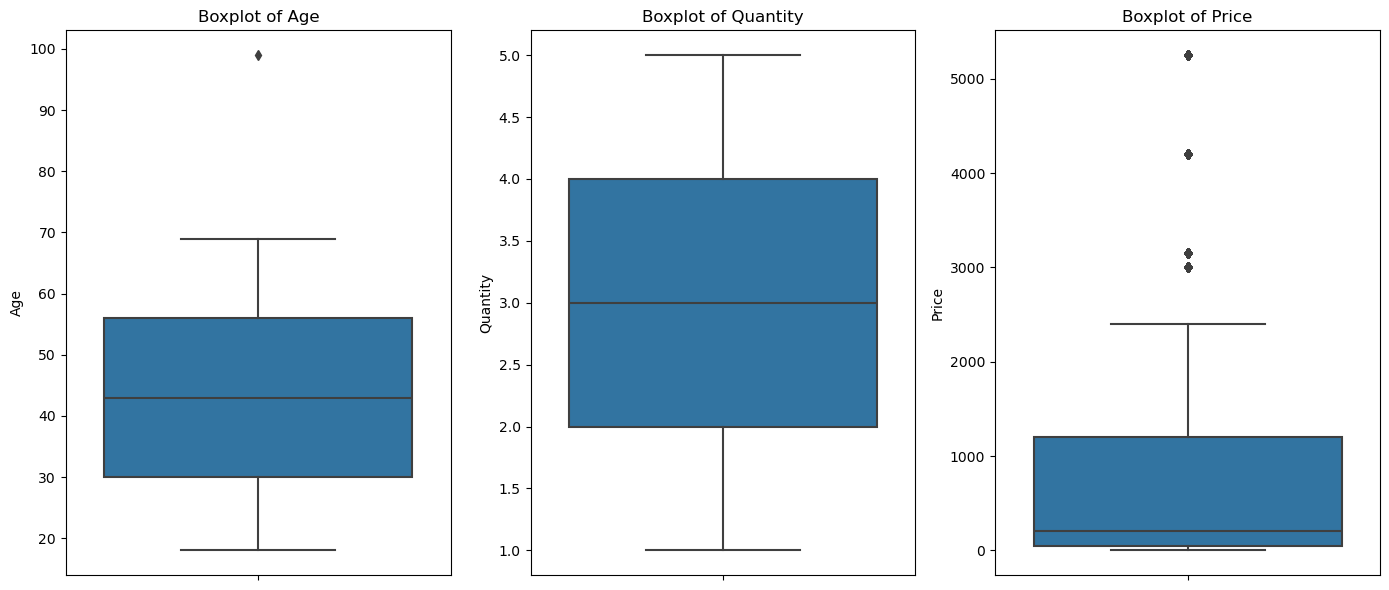

In [442]:
# Create a figure with subplots for each numerical column
plt.figure(figsize=(14, 6))

# Boxplot for the 'age' column
plt.subplot(1, 3, 1)
sns.boxplot(y=final_cus_data['age'])
plt.title('Boxplot of Age')
plt.ylabel('Age')

# Boxplot for the 'quantity' column
plt.subplot(1, 3, 2)
sns.boxplot(y=final_cus_data['quantity'])
plt.title('Boxplot of Quantity')
plt.ylabel('Quantity')

# Boxplot for the 'price' column
plt.subplot(1, 3, 3)
sns.boxplot(y=final_cus_data['price'])
plt.title('Boxplot of Price')
plt.ylabel('Price')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

In [316]:
def remove_outliers(final_cus_data, column):
    Q1 = final_cus_data[column].quantile(0.25)
    Q3 = final_cus_data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Defining the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Removing outliers
    final_cus_data_filtered = final_cus_data[(final_cus_data[column] >= lower_bound) & (final_cus_data[column] <= upper_bound)]
    
    return final_cus_data_filtered

# Removing outliers from the 'age', 'quantity', and 'price' columns
final_cus_data_cleaned = remove_outliers(final_cus_data, 'age')
final_cus_data_cleaned = remove_outliers(final_cus_data_cleaned, 'quantity')
final_cus_data_cleaned = remove_outliers(final_cus_data_cleaned, 'price')

## <span style="color:green">The Whole Dataset is now cleaned.</span>

# **Section 2**


## **Plotting the Foundation for Analysis**

I am expected to perform three analysis techniques from the options below, each backed with visualizations.

Some of the things I may consider are:

Based on my analysis, which customer segments or categories should the shopping mall target for marketing campaigns?
I can create a box plot to compare the distribution of spending scores between male and female customers. What can I infer from the box plot about the spending behavior of different genders?
I can create a scatter plot to visualize the relationship between age and spending. What insights can I derive from this visualization? Is there a correlation between age and spending?
I could segment the customers into different age groups (e.g., 18-25, 26-35, 36-45, 46-55, 56+). How does the spending score vary across these age groups? I will provide a visualization to support my analysis.

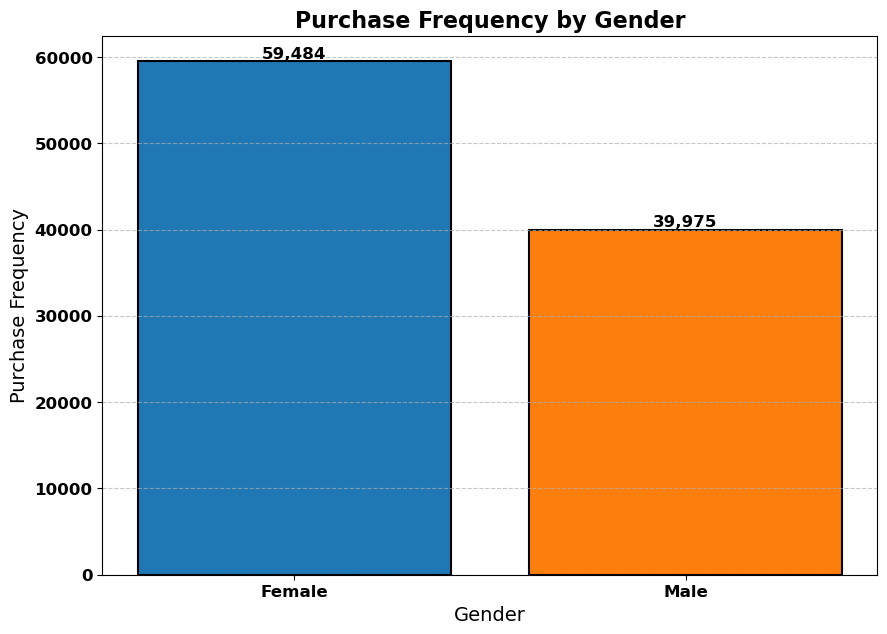

In [433]:
# Assuming cus_data is your DataFrame with relevant data

# Calculate purchase frequency by gender
purchase_frequency = final_cus_data.groupby('gender').size().reset_index(name='Purchase Frequency')

# Data for the plot
genders = purchase_frequency['gender']
frequencies = purchase_frequency['Purchase Frequency']

# Plotting the bar graph
plt.figure(figsize=(10, 7))
bars = plt.bar(genders, frequencies, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.5)

# Adding labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center', fontsize=12, fontweight='bold')

# Adding titles and labels
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Purchase Frequency', fontsize=14)
plt.title('Purchase Frequency by Gender', fontsize=16, fontweight='bold')

# Enhancing the overall look
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

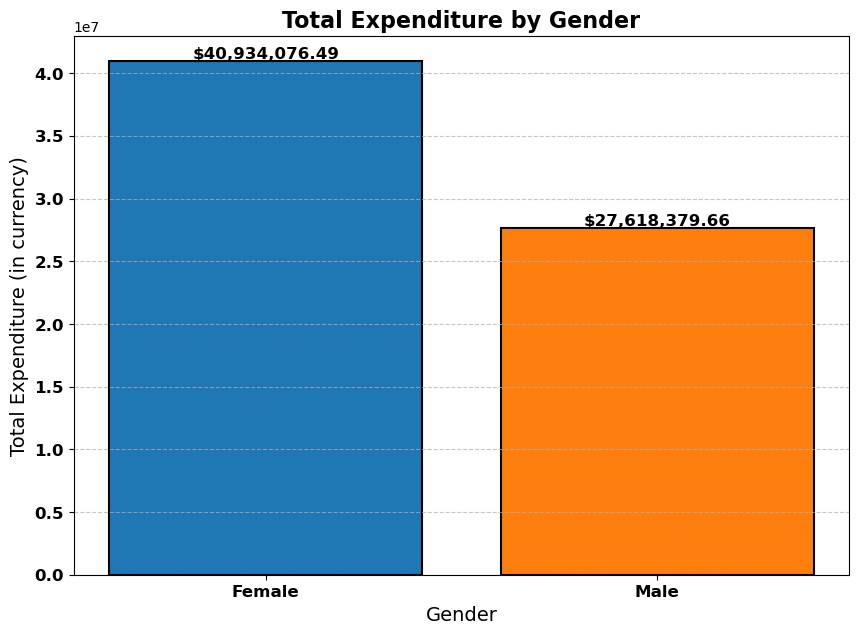

In [321]:
# Calculate the total expenditure by gender
total_expenditure_by_gender = final_cus_data.groupby('gender')['price'].sum().reset_index()
total_expenditure_by_gender.columns = ['Gender', 'Total Expenditure']

# Data for the plot
genders = total_expenditure_by_gender['Gender']
total_expenditure = total_expenditure_by_gender['Total Expenditure']

# Plotting the bar graph
plt.figure(figsize=(10, 7))
bars = plt.bar(genders, total_expenditure, color=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.5)

# Adding labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'${yval:,.2f}', va='bottom', ha='center', fontsize=12, fontweight='bold')

# Adding titles and labels
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Total Expenditure (in currency)', fontsize=14)
plt.title('Total Expenditure by Gender', fontsize=16, fontweight='bold')

plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

/var/folders/9p/yyv7fcs508b7p4xrytxhypc80000gn/T/ipykernel_1405/717049995.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_frequency = cus_data.groupby('age_group').size().reset_index(name='Purchase Frequency')


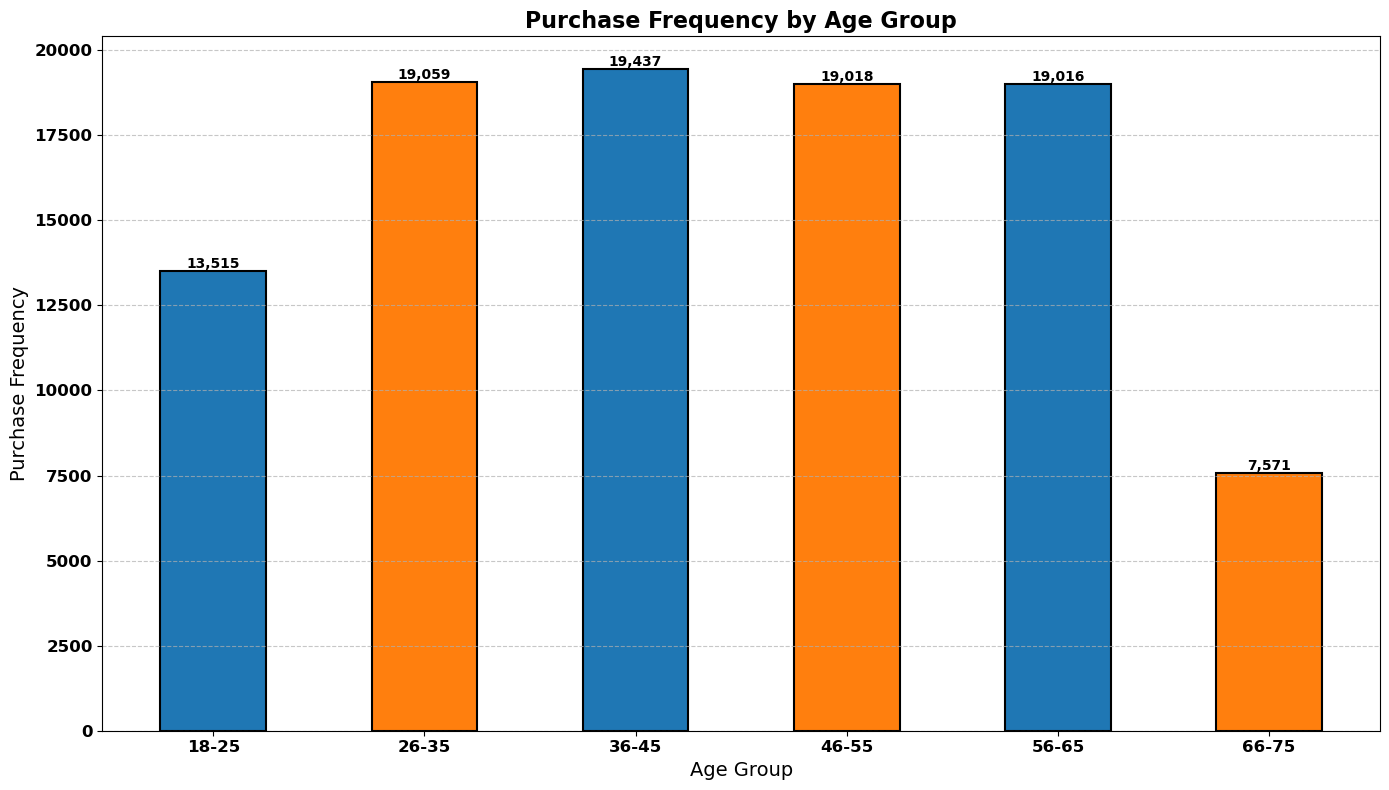

In [322]:
# Binning ages into groups
age_bins = [18, 25, 35, 45, 55, 65, 75]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']
cus_data['age_group'] = pd.cut(cus_data['age'], bins=age_bins, labels=age_labels)

# Calculate purchase frequency by age group
age_frequency = cus_data.groupby('age_group').size().reset_index(name='Purchase Frequency')

# Data for the plot
ages = age_frequency['age_group']
frequencies = age_frequency['Purchase Frequency']

# Create a list of colors alternating between blue and orange
colors = ['#1f77b4' if i % 2 == 0 else '#ff7f0e' for i in range(len(ages))]

# Plotting the bar graph
plt.figure(figsize=(14, 8))  # Adjusting figure size for better spacing
bars = plt.bar(ages, frequencies, color=colors, edgecolor='black', linewidth=1.5, width=0.5)

# Adding labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval,
        f'{yval:,}',
        va='bottom',
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Adding titles and labels
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Purchase Frequency', fontsize=14)
plt.title('Purchase Frequency by Age Group', fontsize=16, fontweight='bold')

# Enhancing the overall look
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

The bar graph shows that people aged 36-45 shop the most, followed by those in the 26-35 and 46-55 age groups. Younger shoppers (18-25) and older ones (56-75) shop less frequently.

This suggests that marketing should focus on those aged 26-55, especially the 36-45 group, as they are the most active shoppers.

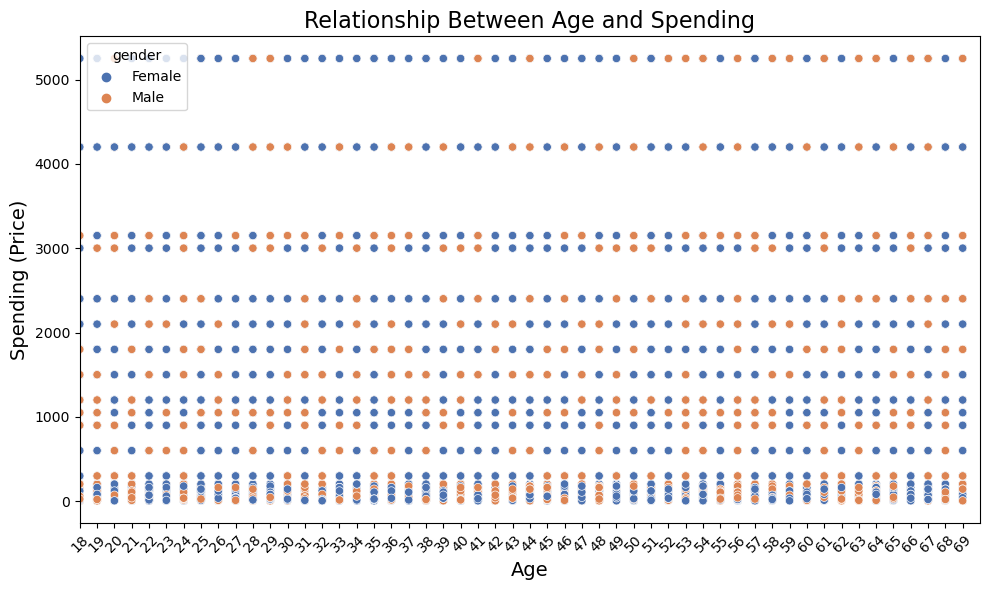

In [326]:
# Scatter plot to visualize the relationship between age and spending
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='price', data=final_cus_data, hue='gender', palette='deep')

# Adding titles and labels
plt.title('Relationship Between Age and Spending', fontsize=16)
plt.xlabel('Age', fontsize=14)
plt.ylabel('Spending (Price)', fontsize=14)

# Set x-axis limits to max at 70
plt.xlim(18, 70)  # Assuming the minimum age is 18, adjust accordingly

# Ensure all ages are shown on the x-axis
plt.xticks(ticks=range(final_cus_data['age'].min(), 70), rotation=45, fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()

The scatter plot shows that spending doesn’t vary much with age, and both men and women have similar spending habits. Age doesn’t seem to be a key factor in how much people spend.

In [329]:
# Calculate the purchase frequency by category and total money spent
category_analysis = final_cus_data.groupby('category').agg(
    Purchase_Frequency=('invoice_no', 'count'),
    Total_Money_Spent=('price', 'sum')
).reset_index()

# Display the result
print(category_analysis)

          category  Purchase_Frequency  Total_Money_Spent
0            Books                4982          226978.29
1         Clothing               34486        31074484.32
2        Cosmetics               15096         1848444.26
3  Food & Beverage               14777          231584.40
4            Shoes               10035        18137737.57
5         Souvenir                4999          174436.83
6       Technology                4996        15772050.00
7             Toys               10088         1086740.48


Clothing dominates both in sales and money spent, making it the top priority for marketing.
Shoes and Technology are high-value categories with fewer purchases but significant spending.
Books and Food & Beverage have many purchases but contribute less to overall revenue.
Cosmetics and Toys show moderate activity, while Souvenir has low spending despite a decent number of purchases.

My recommendation is to focus on Clothing, Shoes, and Technology for maximum impact.

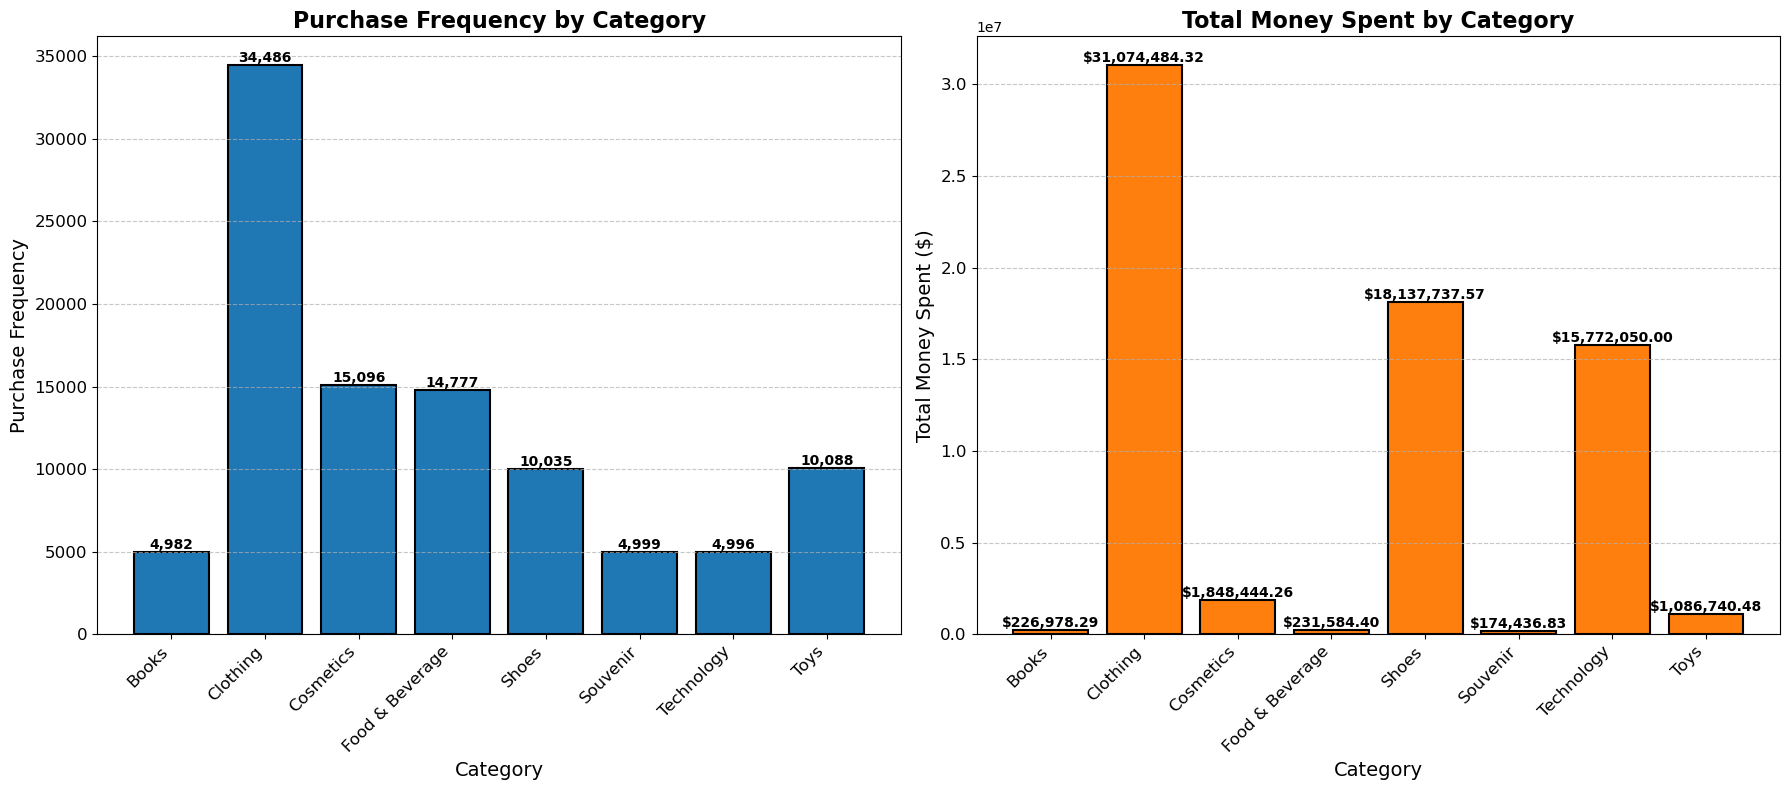

In [335]:
# Calculate the purchase frequency by category and total money spent
category_analysis = final_cus_data.groupby('category').agg(
    Purchase_Frequency=('invoice_no', 'count'),
    Total_Money_Spent=('price', 'sum')
).reset_index()

# Data for the plot
categories = category_analysis['category']
purchase_frequencies = category_analysis['Purchase_Frequency']
total_money_spent = category_analysis['Total_Money_Spent']

# Creating a figure with two subplots
plt.figure(figsize=(18, 8))

# Subplot 1: Purchase Frequency by Category
plt.subplot(1, 2, 1)
bars1 = plt.bar(categories, purchase_frequencies, color='#1f77b4', edgecolor='black', linewidth=1.5)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Purchase Frequency', fontsize=14)
plt.title('Purchase Frequency by Category', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding labels on top of each bar
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:,}', va='bottom', ha='center', fontsize=10, fontweight='bold')

# Subplot 2: Total Money Spent by Category
plt.subplot(1, 2, 2)
bars2 = plt.bar(categories, total_money_spent, color='#ff7f0e', edgecolor='black', linewidth=1.5)
plt.xlabel('Category', fontsize=14)
plt.ylabel('Total Money Spent ($)', fontsize=14)
plt.title('Total Money Spent by Category', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding labels on top of each bar
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'${yval:,.2f}', va='bottom', ha='center', fontsize=10, fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

Clothing dominates both in sales and money spent, making it the top priority for marketing.
Shoes and Technology are high-value categories with fewer purchases but significant spending.
Books and Food & Beverage have many purchases but contribute less to overall revenue.
Cosmetics and Toys show moderate activity, while Souvenir has low spending despite a decent number of purchases.

My recommendation is to focus on Clothing, Shoes, and Technology for maximum impact.

In [435]:
# Load the dataset
final_cus_data = pd.read_csv('customer_shopping_data.csv')

# Calculate the average sales for each category
average_sales = final_cus_data.groupby('category')['price'].mean().reset_index()
average_sales.columns = ['Category', 'Average Sales']

# Display the result
print(average_sales)

          Category  Average Sales
0            Books      45.559673
1         Clothing     901.075344
2        Cosmetics     122.445963
3  Food & Beverage      15.671950
4            Shoes    1807.447690
5         Souvenir      34.894345
6       Technology    3156.935548
7             Toys     107.726059


<Figure size 2000x1200 with 0 Axes>

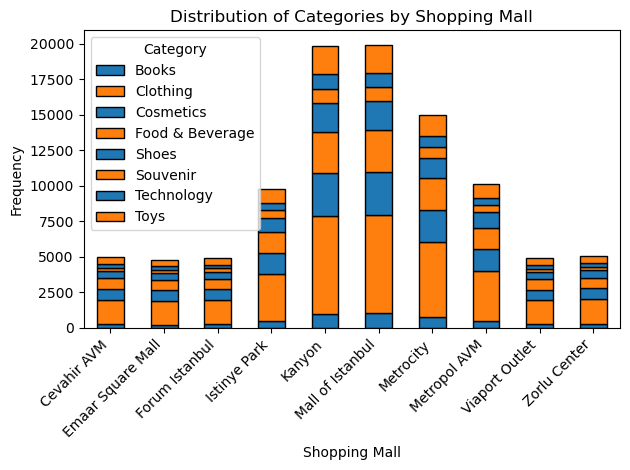

In [450]:
# Counting the occurrences of each shopping mall and category combination
shopping_mall_category_counts = final_cus_data.groupby(["shopping_mall", "category"]).size().unstack()

# Plotting the stacked bar plot
plt.figure(figsize=(20, 12))
shopping_mall_category_counts.plot(kind="bar", stacked=True, color=colors, edgecolor="black")
plt.title("Distribution of Categories by Shopping Mall")
plt.xlabel("Shopping Mall")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

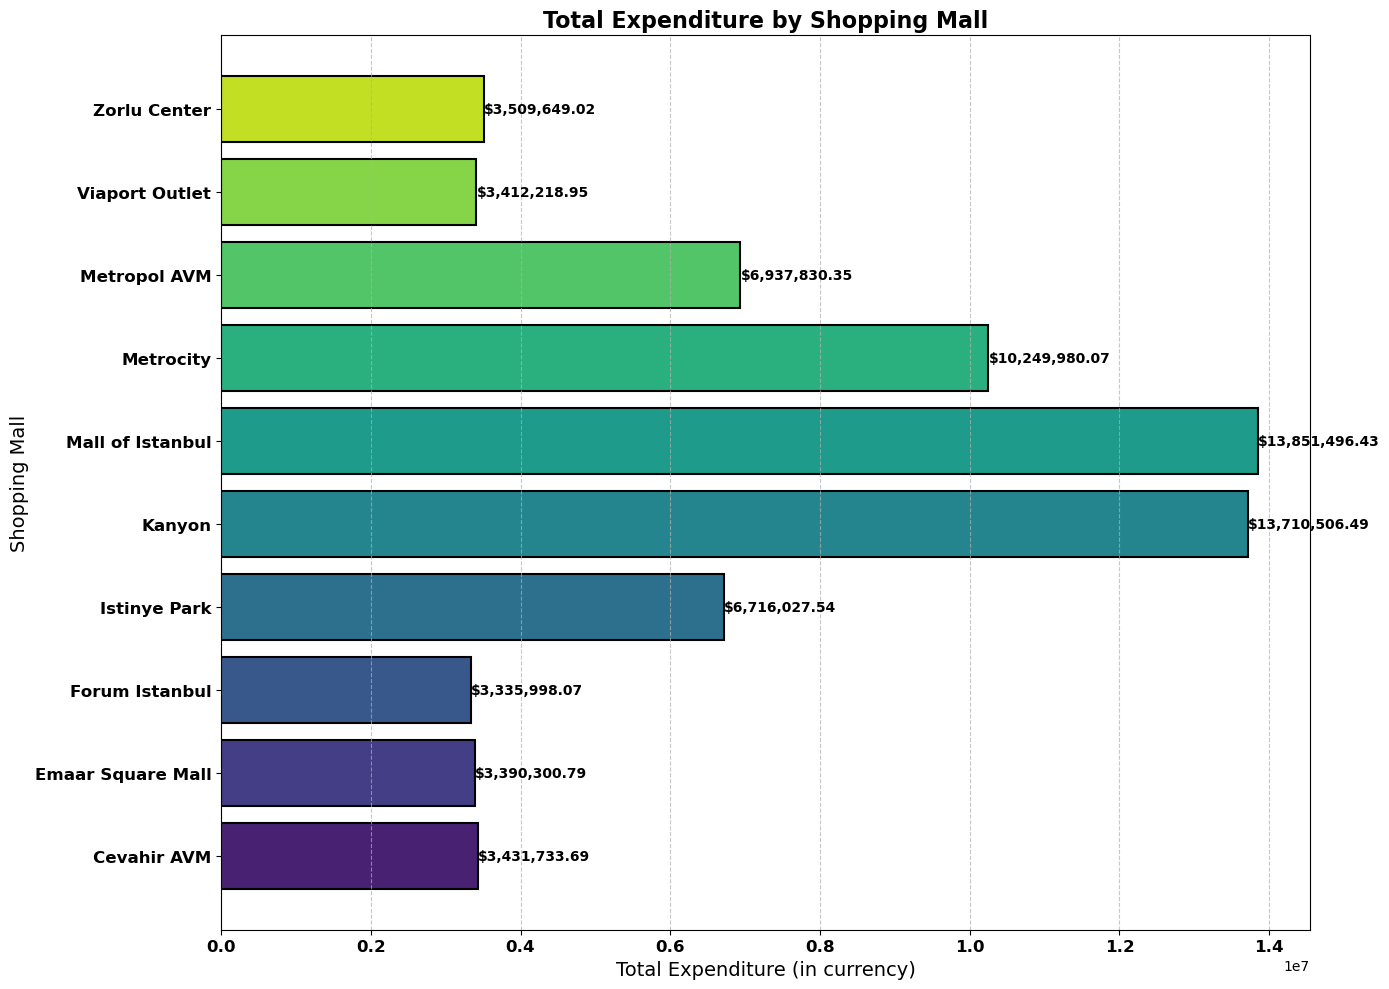

In [483]:
# Calculate total expenditure by shopping mall
mall_expenditure = final_cus_data.groupby('shopping_mall').agg(
    Total_Expenditure=('price', 'sum')
).reset_index()

# Data for the plot
malls = mall_expenditure['shopping_mall']
total_expenditure = mall_expenditure['Total_Expenditure']

# Plotting the horizontal bar graph with colorful bars
plt.figure(figsize=(14, 10))  # Increased figure size for better readability
bars = plt.barh(malls, total_expenditure, color=sns.color_palette("viridis", len(malls)), edgecolor='black', linewidth=1.5)

# Adding labels on the bars
for bar in bars:
    yval = bar.get_width()
    plt.text(yval, bar.get_y() + bar.get_height()/2.0, f'${yval:,.2f}', va='center', ha='left', fontsize=10, fontweight='bold')

# Adding titles and labels
plt.xlabel('Total Expenditure (in currency)', fontsize=14)
plt.ylabel('Shopping Mall', fontsize=14)
plt.title('Total Expenditure by Shopping Mall', fontsize=16, fontweight='bold')

# Enhancing the overall look
plt.xticks(fontsize=12, fontweight='bold')
plt.yticks(fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

The chart shows that Mall of Istanbul and Kanyon lead in total expenditure, making them the most lucrative locations. Metropol AVM and Metrocity also generate significant revenue, positioning them as key shopping destinations.

On the other end, Forum Istanbul, Emaar Square Mall, and Viaport Outlet have lower total spending, indicating these malls might benefit from targeted promotions to boost sales.

Focusing marketing efforts on the top-performing malls could maximize returns, while the lower-performing malls may need more attention to increase their revenue.

/var/folders/9p/yyv7fcs508b7p4xrytxhypc80000gn/T/ipykernel_1405/415902534.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_analysis = final_cus_data.groupby('age_group').agg(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


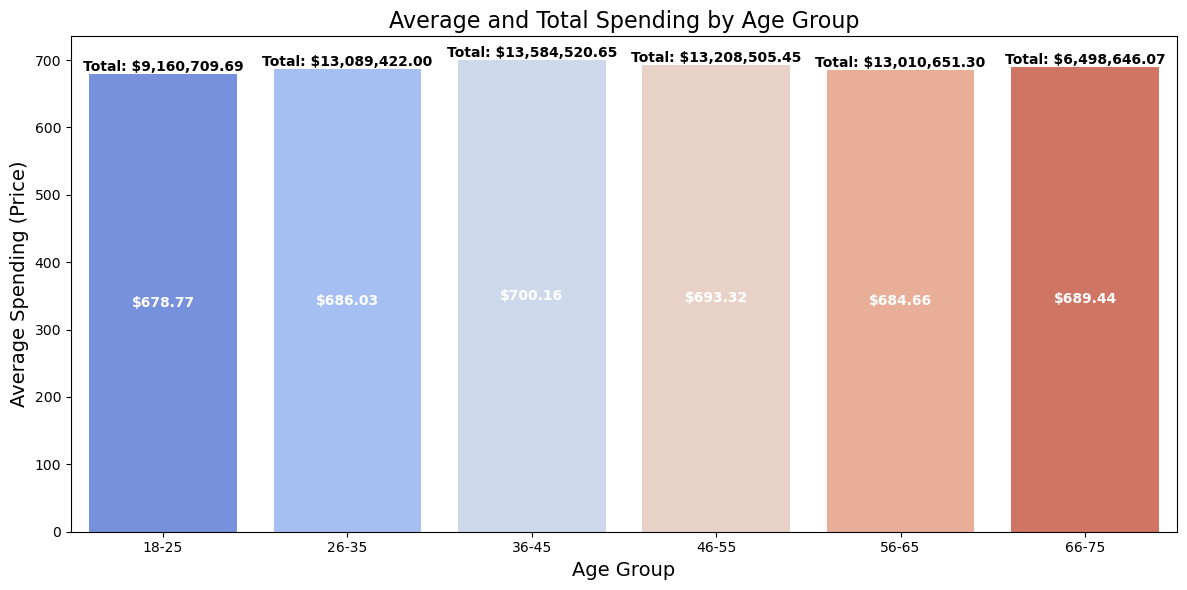

In [456]:
# Segmenting customers into different age groups
age_bins = [18, 25, 35, 45, 55, 65, 75]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']
final_cus_data['age_group'] = pd.cut(final_cus_data['age'], bins=age_bins, labels=age_labels, right=False)

# Calculate total and average spending per age group
age_group_analysis = final_cus_data.groupby('age_group').agg(
    Average_Spending=('price', 'mean'),
    Total_Spending=('price', 'sum')
).reset_index()

# Plotting the average spending per age group with labels inside the bars
plt.figure(figsize=(12, 6))
bars = sns.barplot(x='age_group', y='Average_Spending', data=age_group_analysis, palette='coolwarm')

# Adding average and total spending labels on the bars
for bar, avg_spending, total_spending in zip(bars.patches, age_group_analysis['Average_Spending'], age_group_analysis['Total_Spending']):
    yval = bar.get_height()
    # Display average spending inside the bar
    plt.text(bar.get_x() + bar.get_width()/2.0, yval / 2, f'${avg_spending:,.2f}', va='center', ha='center', fontsize=10, fontweight='bold', color='white')
    # Display total spending above the bar
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'Total: ${total_spending:,.2f}', va='bottom', ha='center', fontsize=10, fontweight='bold')

# Adding titles and labels
plt.title('Average and Total Spending by Age Group', fontsize=16)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Average Spending (Price)', fontsize=14)

plt.tight_layout()
plt.show()

The graph reveals that the 36-45 age group spends the most on average, closely followed by the 46-55 group. These two age groups not only have high average spending but also contribute significantly to the total spending.

Interestingly, the 26-35 age group, while having a slightly lower average spending, still contributes a substantial total, making it a key demographic. The younger (18-25) and older (56-65) age groups have lower average spending, but they still make meaningful contributions.

This suggests that marketing efforts should particularly focus on customers aged 26-55, with special attention to those in the 36-45 range, as they are both frequent and high spenders.

In [ ]:
price_median = final_cus_data['price'].median()
final_cus_data['price'].fillna(price_median, inplace=True)

# Filling missing value in 'payment_method' with the most frequent method
payment_mode_mode = final_cus_data['payment_method'].mode()[0]
final_cus_data['payment_method'].fillna(payment_mode_mode, inplace=True)

Based on the analysis of the data:

- **Target Customer Segments/Categories:** The shopping mall should focus on the *Clothing*, *Shoes*, and *Technology* categories for marketing campaigns. These categories have the highest spending, making them the most profitable segments.

- **Spending Behavior by Gender:** The box plot comparing spending between male and female customers showed that spending habits are similar across genders, with no significant difference. This suggests that marketing efforts can be evenly distributed between men and women.

- **Age and Spending Relationship:** The scatter plot showed that there isn’t a strong correlation between age and spending. Customers of all ages seem to spend similarly, so age might not be a major factor in targeting campaigns.

- **Spending Across Age Groups:** After segmenting customers into age groups, it was clear that the 36-45 age group spends the most, followed closely by the 26-35 and 46-55 groups. Marketing should focus on these age groups, as they are the highest spenders.

This approach ensures that marketing efforts are focused on the most profitable customer segments and categories, while also considering age and gender in a balanced way.


# **Section 3**


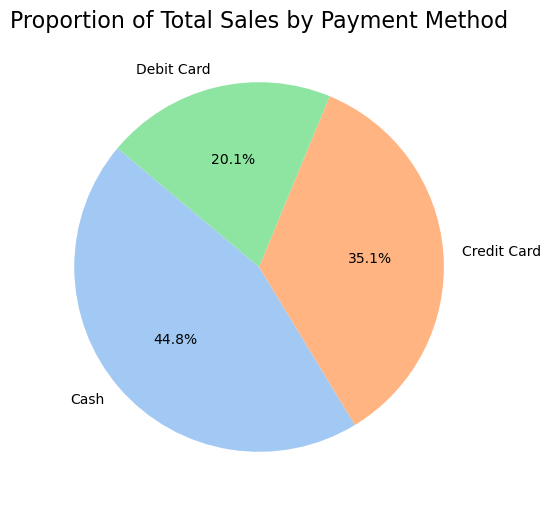

In [479]:
# Calculate total sales by payment method
payment_method_sales = final_cus_data.groupby('payment_method')['price'].sum().reset_index()

# Calculate the proportion of total sales
payment_method_sales['Percentage'] = (payment_method_sales['price'] / payment_method_sales['price'].sum()) * 100

# Plotting the pie chart
plt.figure(figsize=(10, 6))
plt.pie(payment_method_sales['price'], labels=payment_method_sales['payment_method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Proportion of Total Sales by Payment Method', fontsize=16)
plt.show()


The pie chart shows how customers prefer to pay. If one method is used more than others, it means people like it, so I'll make sure it works smoothly. If some methods are used less, I might want to promote them more or make them easier to use.

Recommendation: I'll focus on keeping the most popular payment methods hassle-free. For the less popular ones, I’ll consider offering discounts or making them easier to use to encourage more customers to try them.

In [ ]:
def convert_to_date(val):
    # Check if the value is numeric, which might indicate an Excel serial date number
    if isinstance(val, (int, float)):
        return pd.to_datetime('1899-12-30') + pd.to_timedelta(val, 'D')
    try:
        return pd.to_datetime(val, errors='coerce')
    except:
        return np.nan

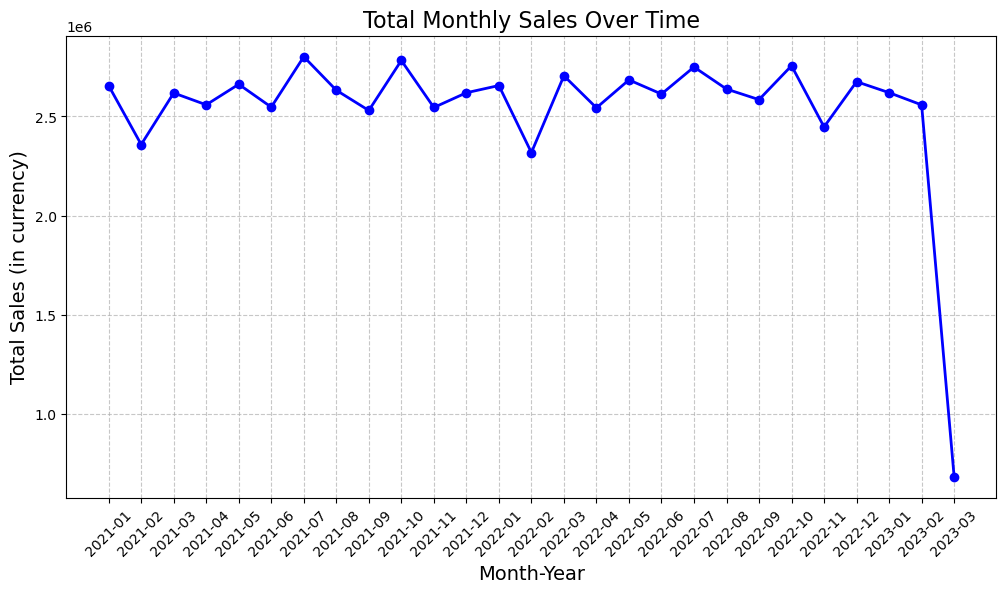

In [481]:
# Apply the function to the 'invoice_date' column
final_cus_data['invoice_date'] = final_cus_data['invoice_date'].apply(convert_to_date)

# Drop rows where date conversion failed
final_cus_data.dropna(subset=['invoice_date'], inplace=True)

# Extract month and year from the date for aggregation
final_cus_data['month_year'] = final_cus_data['invoice_date'].dt.to_period('M')

# Calculate total monthly sales
monthly_sales = final_cus_data.groupby('month_year')['price'].sum().reset_index()

# Plotting the line chart for monthly sales
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['month_year'].astype(str), monthly_sales['price'], marker='o', color='blue', linestyle='-', linewidth=2)
plt.title('Total Monthly Sales Over Time', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Total Sales (in currency)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The chart reveals the trends in sales over different months. If there are noticeable peaks, these might correspond to seasonal trends, holidays, or special promotions. On the other hand, any dips could indicate slower sales periods that may need attention.

Recommendation: Focus on understanding what drives the high-sales months—whether it's a seasonal pattern, effective promotions, or external factors. Consider replicating successful strategies during low-sales months to smooth out revenue fluctuations. Additionally, planning special campaigns during slower periods could help boost sales.

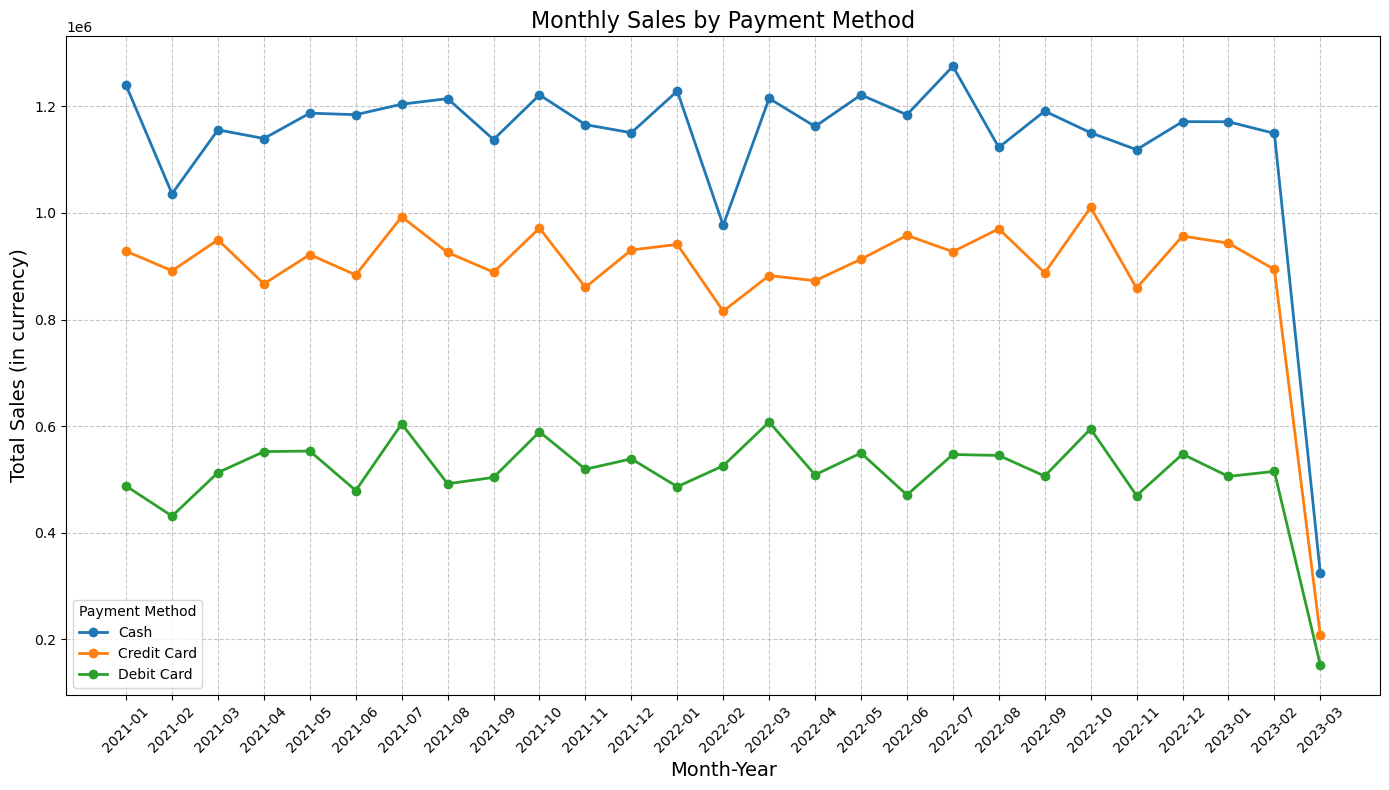

In [490]:
# Extract month and year from the invoice date for grouping
final_cus_data['month_year'] = final_cus_data['invoice_date'].dt.to_period('M')

# Calculate total sales by payment method for each month
monthly_payment_sales = final_cus_data.groupby(['month_year', 'payment_method'])['price'].sum().unstack().reset_index()

# Plotting the line chart for monthly sales by payment method
plt.figure(figsize=(14, 8))
for payment_method in monthly_payment_sales.columns[1:]:
    plt.plot(monthly_payment_sales['month_year'].astype(str), monthly_payment_sales[payment_method], marker='o', linestyle='-', linewidth=2, label=payment_method)

# Adding titles and labels
plt.title('Monthly Sales by Payment Method', fontsize=16)
plt.xlabel('Month-Year', fontsize=14)
plt.ylabel('Total Sales (in currency)', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Payment Method')
plt.tight_layout()

# Display the plot
plt.show()

The chart shows how often customers use different payment methods each month. If cash is more popular than cards, it might be because customers find it easier or aren’t aware of the benefits of using cards.

Recommendation: To encourage more card payments, I want to offer discounts or rewards for using cards. I’d also make sure to highlight the benefits, like security and convenience, both in-store and at checkout. Running special promotions for card users could also help more customers make the switch.

### Recommendations

#### Sales by Payment Method:
- **Visualization Insight:** The pie chart showing the proportion of total sales by payment method indicates that customers have a clear preference for certain payment methods. If card payments (Credit or Debit) dominate, it suggests that customers find them convenient and trustworthy. On the other hand, if cash is more popular, it may be due to customer habits or perceived ease of use.

- **Recommendation:** 
  - **Enhance Card Payment Experience:** If card payments are popular, ensure that the card payment process is seamless and fast. Consider offering loyalty points or discounts for using cards to further encourage this behavior.
  - **Promote Card Payments:** If cash payments dominate, run promotions that reward customers for using cards, such as cashback offers or discounts. Highlight the benefits of card payments, such as security and convenience, through marketing campaigns.

#### Sales Trend Over Time:
- **Visualization Insight:** The line chart showing total monthly sales over time may reveal patterns such as peaks during certain seasons, holidays, or promotional periods, as well as slower months. Identifying these trends is crucial for planning inventory, staffing, and marketing efforts.

- **Recommendation:**
  - **Capitalize on High-Sales Periods:** If there are clear sales peaks, align marketing campaigns, product launches, and promotions with these high-sales periods to maximize revenue. Consider ramping up inventory and staffing during these times to meet demand.
  - **Boost Sales During Slow Months:** For months with lower sales, introduce targeted promotions, discounts, or special events to attract customers. Consider offering limited-time offers or seasonal products to create excitement and drive traffic to the mall during these periods.

These recommendations aim to optimize payment processing and capitalize on sales trends to boost overall revenue and improve the shopping experience.
